In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
#J’ai identifié un problème de parsing du dataset lié au séparateur et corrigé l’import pour structurer correctement les données.
# De base j'avais mis avec un point-virgule, mais le dataset utilise une virgule comme séparateur. 
# J'ai donc modifié le code pour utiliser sep="," lors de la lecture du fichier CSV.   
df = pd.read_csv("data/energy_data.csv", sep=",")
df.head()

,index,Date,Time,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3
0,0,1/1/07,0:00:00,2.58,0.136,241.97,10.6,0,0,0.0
1,1,1/1/07,0:01:00,2.552,0.1,241.75,10.4,0,0,0.0
2,2,1/1/07,0:02:00,2.55,0.1,241.64,10.4,0,0,0.0
3,3,1/1/07,0:03:00,2.55,0.1,241.71,10.4,0,0,0.0
4,4,1/1/07,0:04:00,2.554,0.1,241.98,10.4,0,0,0.0


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 260640 entries, 0 to 260639
Data columns (total 10 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   index                  260640 non-null  int64  
 1   Date                   260640 non-null  str    
 2   Time                   260640 non-null  str    
 3   Global_active_power    260640 non-null  str    
 4   Global_reactive_power  260640 non-null  str    
 5   Voltage                260640 non-null  str    
 6   Global_intensity       260640 non-null  str    
 7   Sub_metering_1         260640 non-null  str    
 8   Sub_metering_2         260640 non-null  str    
 9   Sub_metering_3         256869 non-null  float64
dtypes: float64(1), int64(1), str(8)
memory usage: 19.9 MB


In [9]:
# Drop index car inutile et peut causer des problèmes de manipulation
df.drop(columns=['index'], inplace=True, errors='ignore')

# Convert numeric columns
numeric_cols = [
    "Global_active_power",
    "Global_reactive_power",
    "Voltage",
    "Global_intensity",
    "Sub_metering_1",
    "Sub_metering_2",
    "Sub_metering_3"
]

for col in numeric_cols:
    df[col] = pd.to_numeric(df[col], errors="coerce")

In [26]:
#Pour verifier qu'on a bien convertie les str en valeur numerique et identifier les valeurs manquantes
df.info()
#Pour detecter les valeurs manquantes
df.isna().sum()

<class 'pandas.DataFrame'>
RangeIndex: 260640 entries, 0 to 260639
Data columns (total 10 columns):
 #   Column                 Non-Null Count   Dtype         
---  ------                 --------------   -----         
 0   Date                   260640 non-null  str           
 1   Time                   260640 non-null  str           
 2   Global_active_power    256869 non-null  float64       
 3   Global_reactive_power  256869 non-null  float64       
 4   Voltage                256869 non-null  float64       
 5   Global_intensity       256869 non-null  float64       
 6   Sub_metering_1         256869 non-null  float64       
 7   Sub_metering_2         256869 non-null  float64       
 8   Sub_metering_3         256869 non-null  float64       
 9   DateTime               260640 non-null  datetime64[us]
dtypes: datetime64[us](1), float64(7), str(2)
memory usage: 19.9 MB


Date                        0
Time                        0
Global_active_power      3771
Global_reactive_power    3771
Voltage                  3771
Global_intensity         3771
Sub_metering_1           3771
Sub_metering_2           3771
Sub_metering_3           3771
DateTime                    0
dtype: int64

In [ ]:
df["DateTime"] = pd.to_datetime(df["Date"] + " " + df["Time"])
#Créer de nouvelles fonctionnalités temporelles à partir de la colonne "DateTime" 

C:\Users\hp\AppData\Local\Temp\ipykernel_20340\1610594515.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df["DateTime"] = pd.to_datetime(df["Date"] + " " + df["Time"])


In [ ]:
df.info()
print(df['DateTime'])
print(df['DateTime'].isnull().sum())
#on verifie le nombre de valeurs manquantes dans la colonne DateTime pour s'assurer que la conversion s'est bien passée.

<class 'pandas.DataFrame'>
RangeIndex: 260640 entries, 0 to 260639
Data columns (total 10 columns):
 #   Column                 Non-Null Count   Dtype         
---  ------                 --------------   -----         
 0   Date                   260640 non-null  str           
 1   Time                   260640 non-null  str           
 2   Global_active_power    256869 non-null  float64       
 3   Global_reactive_power  256869 non-null  float64       
 4   Voltage                256869 non-null  float64       
 5   Global_intensity       256869 non-null  float64       
 6   Sub_metering_1         256869 non-null  float64       
 7   Sub_metering_2         256869 non-null  float64       
 8   Sub_metering_3         256869 non-null  float64       
 9   DateTime               260640 non-null  datetime64[us]
dtypes: datetime64[us](1), float64(7), str(2)
memory usage: 19.9 MB
0        2007-01-01 00:00:00
1        2007-01-01 00:01:00
2        2007-01-01 00:02:00
3        2007-01-01 00:03

In [ ]:
#Créer de nouvelles fonctionnalités temporelles à partir de la colonne "DateTime" pour capturer les tendances saisonnières et horaires dans la consommation d'énergie.
df["hour"] = df["DateTime"].dt.hour
df["day_name"] = df["DateTime"].dt.day_name()
df["month"] = df["DateTime"].dt.month
df["is_weekend"] = df["DateTime"].dt.dayofweek >= 5

In [29]:
df[["DateTime", "hour", "day_name", "month", "is_weekend"]].head()

,DateTime,hour,day_name,month,is_weekend
0,2007-01-01 00:00:00,0,Monday,1,False
1,2007-01-01 00:01:00,0,Monday,1,False
2,2007-01-01 00:02:00,0,Monday,1,False
3,2007-01-01 00:03:00,0,Monday,1,False
4,2007-01-01 00:04:00,0,Monday,1,False


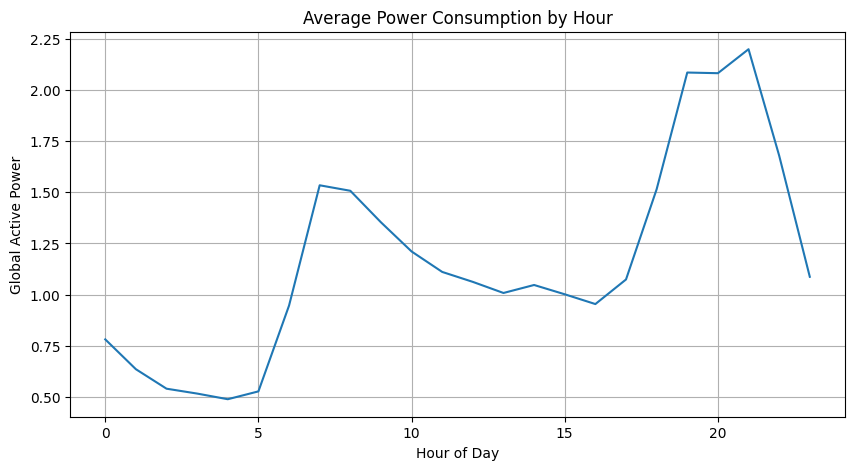

In [30]:
#on analyse la consommation d'énergie en fonction de l'heure de la journée pour identifier les pics de consommation et les périodes creuses via une visualisation graphique.
import matplotlib.pyplot as plt
hourly_avg = df.groupby("hour")["Global_active_power"].mean()
plt.figure(figsize=(10,5))
hourly_avg.plot()
plt.title("Average Power Consumption by Hour")
plt.xlabel("Hour of Day")
plt.ylabel("Global Active Power")
plt.grid(True)
plt.show()

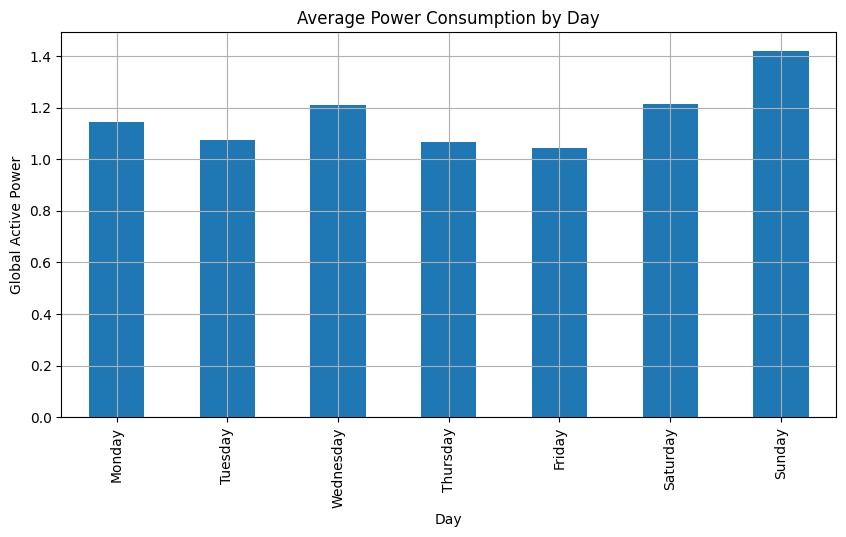

In [31]:
#on analyse la consommation d'énergie en fonction du jour de la semaine pour identifier les tendances hebdomadaires et les différences entre les jours de semaine et les week-ends via une visualisation graphique.
daily_avg = df.groupby("day_name")["Global_active_power"].mean()

daily_avg = daily_avg.reindex([
    "Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"
])

plt.figure(figsize=(10,5))
daily_avg.plot(kind="bar")
plt.title("Average Power Consumption by Day")
plt.xlabel("Day")
plt.ylabel("Global Active Power")
plt.grid(True)
plt.show()

In [32]:
#detection d'anomalies dans la consommation d'énergie en utilisant une méthode simple basée sur l'écart type pour identifier les points de données qui s'écartent significativement de la moyenne.
mean_power = df["Global_active_power"].mean()
std_power = df["Global_active_power"].std()

df["anomaly"] = abs(df["Global_active_power"] - mean_power) > 2 * std_power

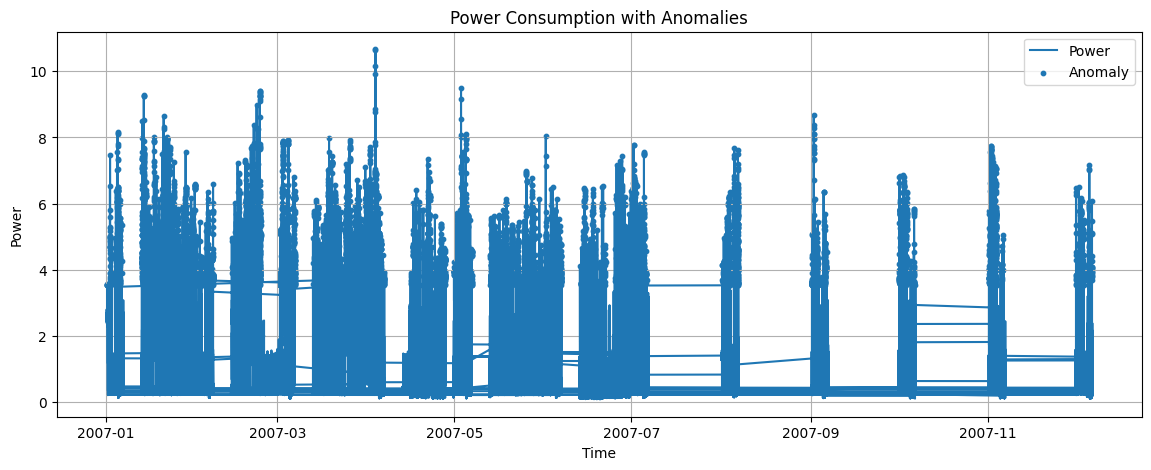

In [35]:
#visualisation des anomalies détectées dans la consommation d'énergie pour identifier les points de données qui s'écartent significativement de la moyenne.
plt.figure(figsize=(14,5))
plt.plot(df["DateTime"], df["Global_active_power"], label="Power")

plt.scatter(
    df.loc[df["anomaly"], "DateTime"],
    df.loc[df["anomaly"], "Global_active_power"],
    s=10,
    label="Anomaly"
)

plt.title("Power Consumption with Anomalies")
plt.xlabel("Time")
plt.ylabel("Power")
plt.legend()
plt.grid(True)
plt.show()

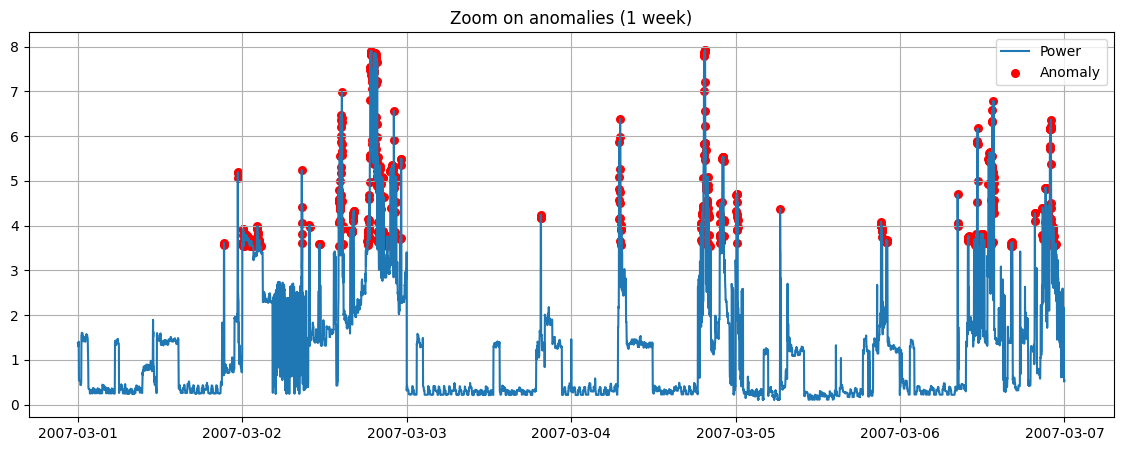

In [36]:
#le graphique est beaucoup trop dense pour visualiser les anomalies clairement, surtout si le dataset est volumineux.
#Une approche plus efficace serait de visualiser les anomalies sur une période plus courte (par exemple une semaine ou un mois) ou d'utiliser des techniques de visualisation plus adaptées pour les séries temporelles, comme les boxplots.
#la je vais visualiser les anomalies sur une semaine pour mieux les identifier
df_sample = df[(df["DateTime"] >= "2007-03-01") & (df["DateTime"] <= "2007-03-07")]

plt.figure(figsize=(14,5))
plt.plot(df_sample["DateTime"], df_sample["Global_active_power"], label="Power")

plt.scatter(
    df_sample.loc[df_sample["anomaly"], "DateTime"],
    df_sample.loc[df_sample["anomaly"], "Global_active_power"],
    color="red",
    s=30,
    label="Anomaly"
)

plt.legend()
plt.title("Zoom on anomalies (1 week)")
plt.grid(True)
plt.show()

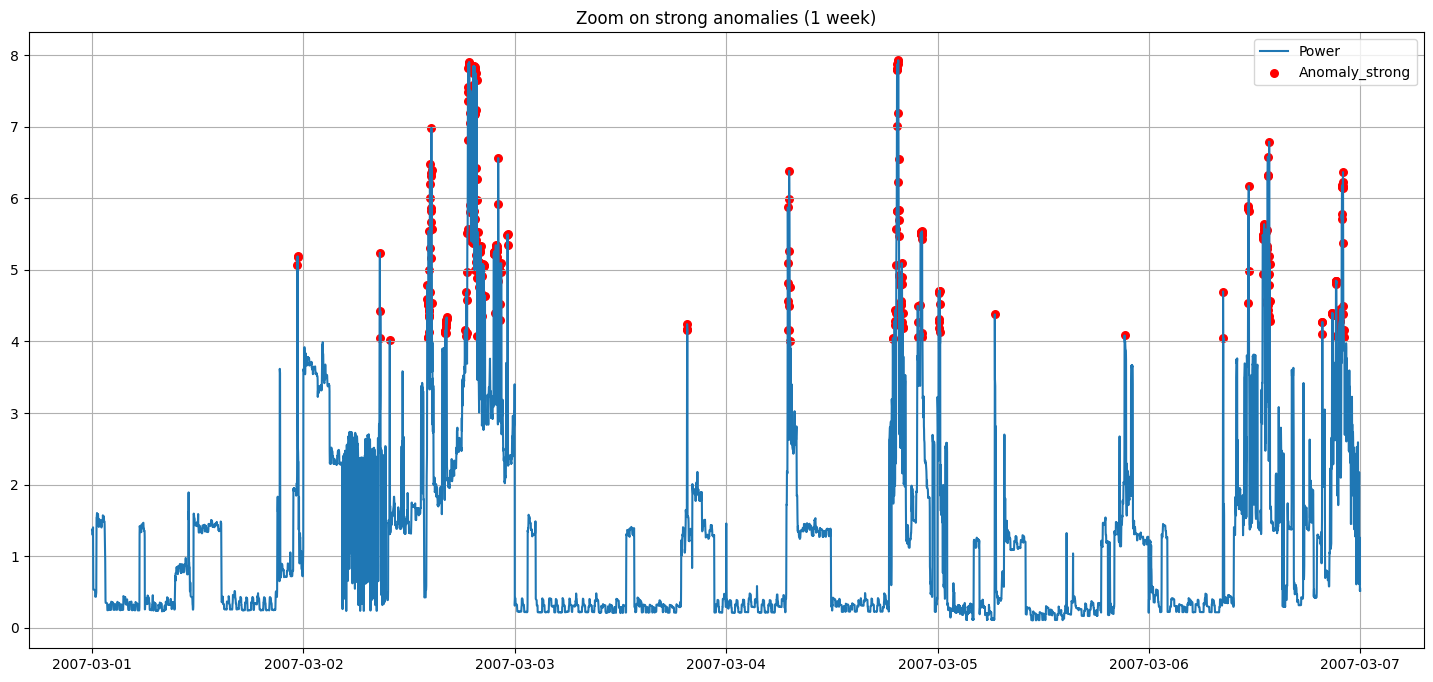

In [40]:
#La détection d’anomalies met en évidence des pics de consommation inhabituels. Cependant, certains de ces pics peuvent correspondre à des comportements normaux liés à des usages énergétiques ponctuels. Ce qu'on peut faire c'est filtrer les anomalies faibles
df["anomaly_strong"] = df["anomaly"] & (df["Global_active_power"] > 4)
df_sample = df[(df["DateTime"] >= "2007-03-01") & (df["DateTime"] <= "2007-03-07")]
plt.figure(figsize=(18,8))
plt.plot(df_sample["DateTime"], df_sample["Global_active_power"], label="Power")

plt.scatter(
    df_sample.loc[df_sample["anomaly_strong"], "DateTime"],
    df_sample.loc[df_sample["anomaly_strong"], "Global_active_power"],
    color="red",
    s=30,
    label="Anomaly_strong"
)

plt.legend()
plt.title("Zoom on strong anomalies (1 week)")
plt.grid(True)
plt.show()

In [ ]:
#La visualisation met en évidence plusieurs anomalies fortes correspondant à des pics de consommation électrique.

#Ces anomalies sont principalement concentrées durant les périodes de forte activité, ce qui suggère qu’elles peuvent être liées à des usages énergétiques spécifiques plutôt qu’à du bruit aléatoire.

#Cependant, certaines anomalies détectées peuvent correspondre à des comportements normaux pendant les heures de pointe, ce qui met en évidence les limites d’une méthode de détection basée sur un seuil global.

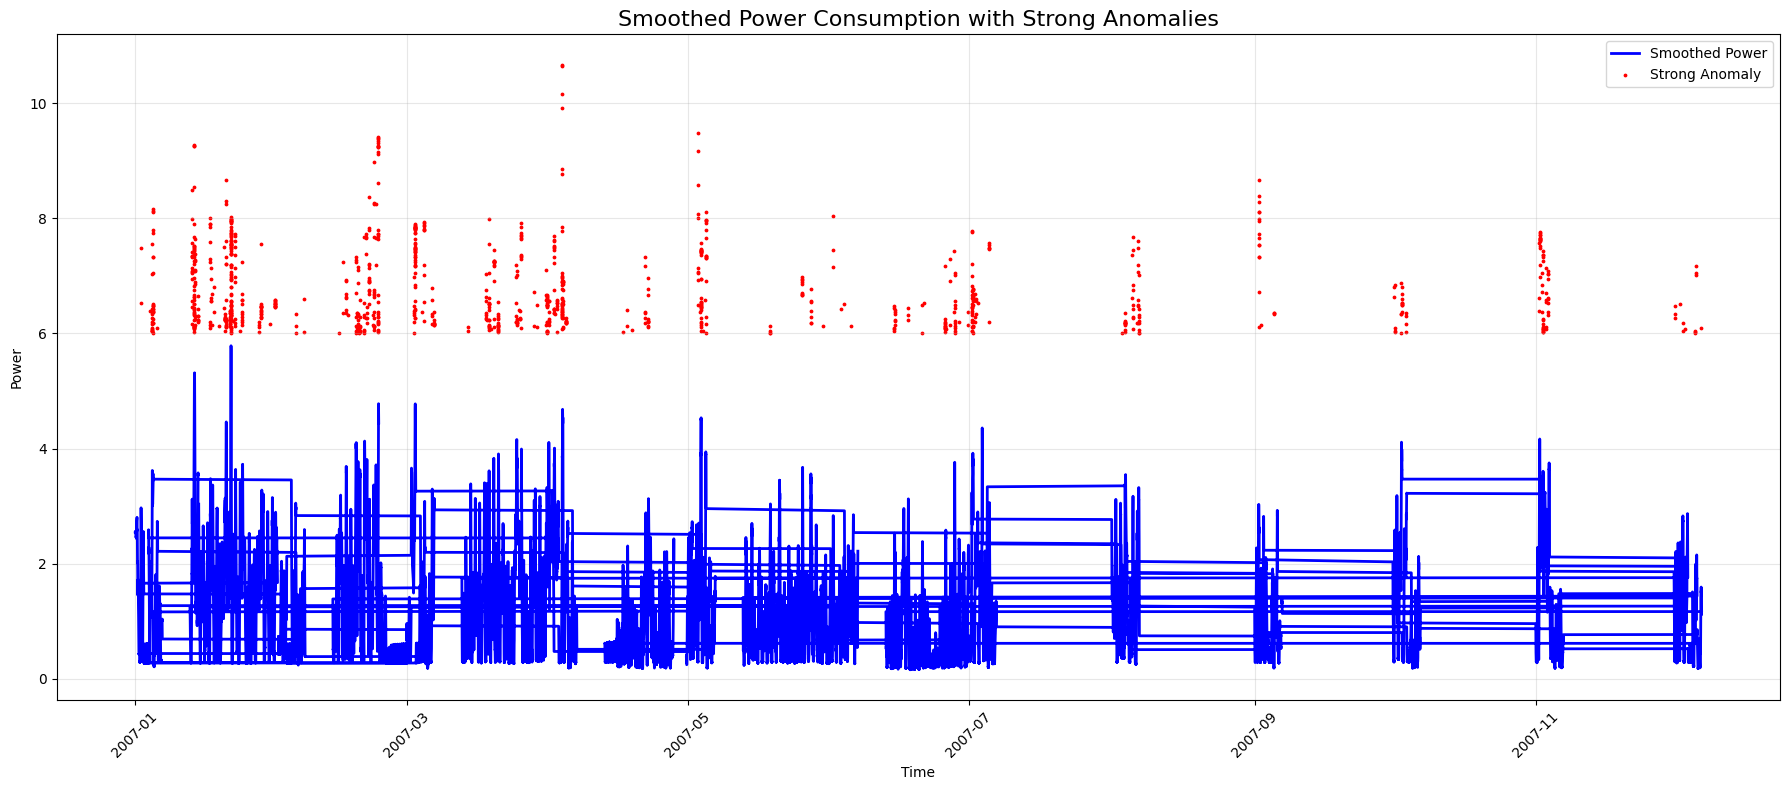

In [44]:
#Pour améliorer la détection d’anomalies, on peut appliquer un lissage sur la série temporelle pour mieux identifier les tendances et les écarts significatifs. Par exemple, en utilisant une moyenne mobile pour lisser les données avant de détecter les anomalies.
df["anomaly_strong"] = df["anomaly"] & (df["Global_active_power"] > 6)
#J'ai augmenté le seuil pour ne garder que les anomalies les plus fortes, ce qui permet de mieux visualiser les pics de consommation significatifs.
df["rolling_mean"] = df["Global_active_power"].rolling(window=180).mean()

plt.figure(figsize=(18,8))

plt.plot(
    df["DateTime"],
    df["rolling_mean"],
    label="Smoothed Power",
    linewidth=2,
    color="blue"
)

plt.scatter(
    df.loc[df["anomaly_strong"], "DateTime"],
    df.loc[df["anomaly_strong"], "Global_active_power"],
    color="red",
    s=3,
    label="Strong Anomaly"
)

plt.legend()
plt.title("Smoothed Power Consumption with Strong Anomalies", fontsize=16)
plt.xlabel("Time")
plt.ylabel("Power")
plt.grid(True, alpha=0.3)

plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

In [34]:
### limites de la méthode
#Cette approche basée sur la moyenne globale et l’écart-type permet une première détection rapide des anomalies.

#Cependant, elle présente des limites importantes :
#- elle ne prend pas en compte la dimension temporelle des données,
#- elle suppose que le comportement de consommation est constant dans le temps,
#- elle peut considérer comme anormales des valeurs pourtant normales à certaines heures (ex : pic en soirée).

#Une approche plus robuste consiste à analyser les anomalies en fonction du contexte temporel (par exemple par heure ou par jour).

In [ ]:
#On va donc analyser les anomalies en fonction de l'heure pour mieux identifier les pics de consommation spécifiques à certaines périodes de la journée.
